In [1]:
import os 
import sys

running_path = "/Odyssey/private/o23gauvr/code/"
os.chdir(running_path)
sys.path.insert(0,running_path)

In [2]:
import pickle
from pathlib import Path
import torch
import torch.nn as nn
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import math


from FASCINATION.src.utils import unorm_ssp_arr_3D

from compressai.ans import RansDecoder

from MLIC.MLIC.utils.utils import Config
from MLIC.MLIC.models import MLICPlusPlus
from MLIC.MLIC.utils.ckbd import *
from MLIC.MLIC.modules.transform import *
from compressai.ops import quantize_ste



In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:


def parse_experiment_config(ckpt_path):
    """
    Parse experiment_config.log file to extract N and M values.
    
    Args:
        ckpt_path (str): PosixPath to checkpoint 
        
    Returns:
        tuple: (N, M) values or (None, None) if parsing fails
    """

    config_file = list((ckpt_path.parent.parent).rglob("train_*.log")) 
    if not config_file:
        print(f"Warning: train logs not found in {ckpt_path}")
        return None, None
    
    config_file = config_file[0]  # Get the first match if multiple found

    try:
        with open(config_file, 'r') as f:
            content = f.read()
        
        # Extract N and M values from MODEL CONFIGURATION section
        N, M = None, None
        
        lines = content.split('\n')

        cfg = eval((lines[1].strip().split("INFO: ")[-1]).replace("<class 'torch.nn.modules.activation.","nn.").replace("'>",""))


        return cfg
        
        # N = cfg['N']
        # M = cfg['M']

    #     if N is not None and M is not None:
    #         print(f"Extracted from {model_path}: N={N}, M={M}")
    #         return N, M
    #     else:
    #         print(f"Warning: Could not extract N and M from {model_path}")
    #         return None, None
            
    except Exception as e:
        print(f"Error parsing config file in {ckpt_path}: {e}")
        return None



In [5]:
def compute_total_bits(out_net):
    return sum(torch.log(likelihoods).sum() / (-math.log(2))
              for likelihoods in out_net['likelihoods'].values()).item()

In [6]:
with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_4_157_196_256.pkl", "rb") as f:
    dm_mlic = pickle.load(f)

In [7]:
depth_array = dm_mlic.depth_array
test_ssp_arr = dm_mlic.test_da.data
season_idx = dm_mlic.test_da.season_idx


In [8]:
data = "enatl"  # "natl" or "enatl"

sst_path = {"enatl": "/Odyssey/public/enatl60/sst/eNATL60-BLB002-SST-2009-2010-1_20.nc",
            "natl": "/Odyssey/public/natl60/sst/NATL60_IFREMER_sources_and_sst_2016_2017.nc"}

sst_da = xr.open_dataarray(sst_path[data])

In [9]:

sst_train = sst_da.interp_like(dm_mlic.train_dataloader().dataset.input, method="nearest").data
sst_test = sst_da.interp_like(dm_mlic.test_dataloader().dataset.input, method="nearest").data

# Compute mean and std from train SST
sst_mean = sst_train.mean()
sst_std = sst_train.std()

# Normalize SST arrays
#sst_train_norm = (sst_train - sst_mean) / sst_std
sst_test_norm = (sst_test - sst_mean) / sst_std

In [10]:
mlic_ckpt_dict = {}

base_dir = "/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/MLIC++/full_loss/batch_size_4" #"/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/MLIC++"#"/Odyssey/private/o23gauvr/code/MLIC/experiments/keep"


# List the first-level directories in the base directory
first_level_dirs = next(os.walk(base_dir))[1]

# Iterate through the first-level directories
for dir_name in first_level_dirs:
    if dir_name == "mute":
        continue
    # Create the relative path
    relative_path = os.path.join(base_dir, dir_name)
    # Add to the dictionary
    mlic_ckpt_dict[dir_name] = relative_path

# Print the dictionary
print(mlic_ckpt_dict)


for model_carac in mlic_ckpt_dict.keys():

    ckpt_list =  list(Path(mlic_ckpt_dict[model_carac]).rglob('checkpoint_best_loss.pth.tar'))
    ckpt_list += list(Path(mlic_ckpt_dict[model_carac]).rglob('best_checkpoint_loss.pth.tar'))
    print(f"Model {model_carac} with {len(ckpt_list)} checkpoints")

{'checkpoints': '/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/MLIC++/full_loss/batch_size_4/checkpoints', 'tb_logger': '/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/MLIC++/full_loss/batch_size_4/tb_logger'}
Model checkpoints with 1 checkpoints
Model tb_logger with 0 checkpoints


In [11]:
bit_rates = {}
outputs = {}

for model_name, model_path in tqdm(mlic_ckpt_dict.items(), desc="SSP MLIC++ models"):
    # Find the best checkpoint
    ckpt_files = list(Path(model_path).rglob('checkpoint_best_loss.pth.tar'))
    ckpt_files += list(Path(model_path).rglob('best_checkpoint_loss.pth.tar'))
    if not ckpt_files:
        print(f"No checkpoint found for {model_name}")
        continue
        
    for ckpt_file in ckpt_files:

        print(f"\nLoading {ckpt_file}")
        
        # Automatically extract N and M from experiment_config.log
        cfg = parse_experiment_config(ckpt_file)

        N = cfg.get('N', 192)
        M = cfg.get('M', 320)

        if cfg.get("in_channels",None) == 3:
            print("Skipping RGB models")
            continue

        if cfg.get('add_embedded_seasons', None) == True:
            cfg["add_seasons"] = {"use": True, "mode": "embed"}

        if "one_hot" in str(ckpt_file):
            cfg["add_seasons"] = {"use": True, "mode": "one_hot"}
            print("Using one_hot season encoding")

        # if N is None or M is None:
        #     print(f"Could not extract N and M for {model_name}, set to default values 192,320.")
        #     N,M = 192,320
        #     #continue
        
        # Create config for this model
        ssp_config = Config({
            "N": N,
            "M": M,
            "slice_num": cfg.get('slice_num', 10),
            "context_window": cfg.get('context_window', 5),
            "act": cfg.get('act', nn.GELU),
            "in_channels": cfg.get("in_channels"),
            "out_channels": cfg.get("in_channels"),
            "add_seasons": cfg.get("add_seasons", {"use": False, "mode": None}),
            "add_sst": cfg.get("add_sst", False),
        })
        
        # Load the model
        try:
            ssp_mlic_net = MLICPlusPlus(config=ssp_config).eval().to(device)
            checkpoint = torch.load(ckpt_file, map_location=device, weights_only=False)

            if "one_hot_old" in str(ckpt_file):
                del checkpoint['state_dict']["season_embed.weight"]

            ssp_mlic_net.load_state_dict(checkpoint['state_dict'])
            
            # Process the data
            x = torch.tensor(test_ssp_arr.copy()).to(device)
            
            with torch.no_grad():
                rv = ssp_mlic_net(x, season_idx, sst_test_norm)

            # Compute metrics
            bits = compute_total_bits(rv)
            numel = rv['x_hat'].numel()
            original_bits = numel * 8
            
            bpe = bits / numel
            cr = original_bits / bits
            

            if len(ckpt_files)>1:
                sub_name = "_" + (str(ckpt_file).split(f'{model_name}/')[-1]).split('/')[0]
            else:
                sub_name = ""
            dict_model_name = (model_name.split("mlicpp_on_ssp_")[-1]).split("_min_max")[0] + sub_name

            bit_rates[dict_model_name] = {}
            outputs[dict_model_name] = {}
                
            # Store under unified name with different CR values
            bit_rates[dict_model_name][cr] = {
                "bits_per_element": bpe,
                "compression_rate": cr,
                "total_compressed_bits": bits,
                "total_original_bits": original_bits,
                "model_config": f"N={N}, M={M}",  # Store config info for reference
                "original_model_name": model_name  # Store original name for reference
            }
            
            reconstructed_arr = rv['x_hat'].detach().cpu().numpy()
            unorm_reconstructed_arr = unorm_ssp_arr_3D(reconstructed_arr, dm_mlic)
            outputs[dict_model_name][cr] = unorm_reconstructed_arr
            
            print(f"  Model config: N={N}, M={M}")
            print(f"  Compression rate: {cr:.2f}x, Bits per element: {bpe:.4f}")
            print(f"  Stored as '{dict_model_name}' with CR {cr:.2f}x")
            
        except Exception as e:
            print(f"Error loading {model_name}: {e}")
            continue

SSP MLIC++ models:   0%|          | 0/2 [00:00<?, ?it/s]


Loading /Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/MLIC++/full_loss/batch_size_4/checkpoints/checkpoint_best_loss.pth.tar


/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538435607/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
SSP MLIC++ models: 100%|██████████| 2/2 [00:03<00:00,  1.91s/it]

  Model config: N=64, M=96
  Compression rate: 649219.94x, Bits per element: 0.0000
  Stored as 'checkpoints' with CR 649219.94x
No checkpoint found for tb_logger


In [12]:
import math, torch

# total compressed bits from likelihoods dict (same as compute_total_bits)
total_bits = sum(torch.log(l).sum() / (-math.log(2)) for l in rv['likelihoods'].values()).item()
numel = rv['x_hat'].numel()
bits_per_element = total_bits / numel
original_bits = numel * 8
cr = original_bits / total_bits
total_bits, bits_per_element, original_bits, cr

(3518.363525390625, 1.2322480490992004e-05, 2284191744, 649219.936347083)

In [13]:
compress_dict = ssp_mlic_net.compress(x)

In [14]:
def count_bits(obj):
    """
    Recursively count total bits in any nested Python structure
    containing bytes objects (lists, tuples, dicts...).
    """
    if isinstance(obj, bytes):
        return len(obj) * 8  # bytes → bits
    elif isinstance(obj, (list, tuple)):
        return sum(count_bits(x) for x in obj)
    elif isinstance(obj, dict):
        return sum(count_bits(v) for v in obj.values())
    else:
        return 0  # ignore non-bytes

In [15]:
count_bits(compress_dict["strings"])

5216

In [16]:
compress_dict['strings']

[[b'PX$\x89\x10\x00\x00\x00<\xb7[\x00\xfe\xff*\xce\xfc}#\x9a\xffj\xfa;\xfe\xff\xab\xd8\xda\x0b\x94\xeb\xc5C\xa1\xd8\x00\xf3\r\x16\xc8\x1a\xf7\x8a\x11S\xe2\xa2s\xb3H\xf3>vm\x1ei\x04\xd3\xe6_\xc4\xaeW\x84\xcev\xac\x98I kJSZ\x9e\x9bLR\xae\xf2EA1]\xf0\xe4\xe6\x19G9\xfa\xfd\xffYX\xfd\xffI#\xa5\xd5\x8c\x9cZN\xb7\x84\x9a\xb6\x02V+\xe0\x8b\xd7\xfc\xad,}\xc6\x12\xd5\xb6_qK\xf1\x94\n\xc0\xe5\x1fh#:\xf8BS,L\xddi\x97\xbe\x1f\x0e\x10\x00\xcd\xbd\x8a\xe4\x9f\xbf\x08\x1a\x18\x89\xe1\xfc@\x12\xf1k\xa8\x08\x8b\xddEH\x15\xe3J\x84N\x83\x9e\xd64\x81al\x92\x90X\x85\x1d.c\x84.\xc0\xb1\xa0\x89R\xa5% \xb1\xc6\x95\xce\xb1+U\x9c(\xb3\xe4\xddO\x98fX}\xa7\xd47\x81\x9b\xcf\xb5\x95\xe0x\xd33HT\x0e\xd4\xea\x14q*.*\x88@\xed\xc8\xab\x96\xbc\x11z\xab\xde9\xe2'],
 [b'\x1d\xe0\xb9,\x94\xfcH1',
  b'I\xb8\x8c#\x0e\x00\x00\x00~\xfb\xf1\xa7',
  b'\x14 g\x0b\xf7\x00\x00\x00\x9ed!}',
  b'm,\t\x94/\x00\x00\x00\x1eg\x93\xe3',
  b'g\t\xc7d\xdc\xdc!(',
  b'\xc8\xe8\xc6\x97\x18\x00\x00\x00\xa0\xfcI\xad',
  b'\xa4~\xbd\xda\x07\x00\x

In [17]:
ssp_mlic_net.decompress(compress_dict["strings"],compress_dict["shape"])

{'x_hat': tensor([[[[0.8344, 0.8330, 0.8322,  ..., 0.8612, 0.8608, 0.8598],
           [0.8362, 0.8346, 0.8343,  ..., 0.8605, 0.8619, 0.8584],
           [0.8343, 0.8322, 0.8329,  ..., 0.8607, 0.8604, 0.8599],
           ...,
           [0.6432, 0.6426, 0.6322,  ..., 0.7960, 0.7996, 0.7990],
           [0.6241, 0.6358, 0.6412,  ..., 0.7884, 0.7890, 0.7893],
           [0.6023, 0.6188, 0.6372,  ..., 0.7814, 0.7813, 0.7855]],
 
          [[0.8339, 0.8312, 0.8316,  ..., 0.8506, 0.8499, 0.8487],
           [0.8352, 0.8327, 0.8331,  ..., 0.8488, 0.8492, 0.8481],
           [0.8341, 0.8311, 0.8324,  ..., 0.8489, 0.8477, 0.8480],
           ...,
           [0.6416, 0.6413, 0.6306,  ..., 0.7963, 0.7992, 0.7989],
           [0.6235, 0.6360, 0.6409,  ..., 0.7875, 0.7876, 0.7884],
           [0.6000, 0.6174, 0.6358,  ..., 0.7803, 0.7793, 0.7841]],
 
          [[0.8322, 0.8299, 0.8303,  ..., 0.8430, 0.8421, 0.8397],
           [0.8335, 0.8312, 0.8312,  ..., 0.8413, 0.8422, 0.8406],
           [0.8

# Lattent space optimization from observations Y

In [18]:
x_train = torch.tensor(dm_mlic.train_da.data).to(device)

In [19]:
x = torch.tensor(test_ssp_arr.copy()).to(device)
x.mean()

tensor(0.4620, device='cuda:0')

In [20]:
obs = x[0,:].unsqueeze(0)
obs.shape

torch.Size([1, 157, 192, 256])

In [21]:
obs[:,0,:,:].shape

torch.Size([1, 192, 256])

In [22]:
mask = torch.zeros_like(obs[:,0,:,:])
torch.manual_seed(42)

n=100

numel = mask.numel()
n = min(int(n), numel)
idx = torch.randperm(numel, device=mask.device)[:n]
mask.view(-1)[idx] = 1
mask = mask.unsqueeze(1).repeat(1,x.shape[1],1,1)
mask.shape


torch.Size([1, 157, 192, 256])

In [23]:
B, C, H, W = x.shape

In [24]:
def phi(model, x):
    model.update_resolutions(x.size(2) // 16, x.size(3) // 16)
    y = model.g_a(x)
    z = model.h_a(y)
    _, z_likelihoods = model.entropy_bottleneck(z)
    return z, z_likelihoods
#z_offset = ssp_mlic_net.entropy_bottleneck._get_medians()
#z_hat = quantize_ste(z - z_offset) + z_offset

z, z_likelihoods = phi(ssp_mlic_net, x)
z.shape

torch.Size([37, 64, 3, 4])

In [25]:
def phi_v2(model, x, quantization=True):
    """
    Differentiable compression pass without entropy coding.
    Returns:
        z_hat: latent Z
        y_hat: latent Y after CKBD slicing and reconstruction
    """
    # Encode
    model.update_resolutions(x.size(2) // 16, x.size(3) // 16)
    y = model.g_a(x)
    z = model.h_a(y)

    z_offset = model.entropy_bottleneck._get_medians()
    z_hat = quantize_ste(z - z_offset) + z_offset  # STE rounding
    hyper_params = model.h_s(z_hat)
    hyper_scales, hyper_means = hyper_params.chunk(2, 1)

    # Process slices
    y_slices = y.chunk(model.slice_num, dim=1)
    y_hat_slices = []

    for idx, y_slice in enumerate(y_slices):
        slice_anchor, slice_nonanchor = ckbd_split(y_slice)

        if idx == 0:
            # -------- ANCHOR --------
            params_anchor = model.entropy_parameters_anchor[idx](hyper_params)
            scales_anchor, means_anchor = params_anchor.chunk(2, 1)
            scales_anchor = ckbd_anchor(scales_anchor)
            means_anchor  = ckbd_anchor(means_anchor)

            if quantization:
                # STE quantize anchor
                slice_anchor = quantize_ste(slice_anchor - means_anchor) + means_anchor
            else:
                slice_anchor = slice_anchor


            # residual predictor
            lrp_anchor = model.lrp_anchor[idx](torch.cat(([hyper_means] + 
                                                         y_hat_slices + 
                                                         [slice_anchor]), dim=1))
            slice_anchor = slice_anchor + ckbd_anchor(lrp_anchor)

            # -------- NON-ANCHOR --------
            local_ctx = model.local_context[idx](slice_anchor)
            params_nonanchor = model.entropy_parameters_nonanchor[idx](
                torch.cat([local_ctx, hyper_params], dim=1)
            )
            scales_nonanchor, means_nonanchor = params_nonanchor.chunk(2, 1)
            scales_nonanchor = ckbd_nonanchor(scales_nonanchor)
            means_nonanchor  = ckbd_nonanchor(means_nonanchor)


            if quantization:
                # STE quantize non-anchor
                slice_nonanchor = quantize_ste(slice_nonanchor - means_nonanchor) + means_nonanchor
            else:
                slice_nonanchor = slice_nonanchor

            lrp_nonanchor = model.lrp_nonanchor[idx](torch.cat(([hyper_means] + 
                                                                y_hat_slices + 
                                                                [slice_nonanchor + slice_anchor]), dim=1))
            slice_nonanchor = slice_nonanchor + ckbd_nonanchor(lrp_nonanchor)

            y_hat_slices.append(slice_nonanchor + slice_anchor)

        else:
            # -------- ANCHOR --------
            global_inter_ctx = model.global_inter_context[idx](torch.cat(y_hat_slices, dim=1))
            channel_ctx      = model.channel_context[idx](torch.cat(y_hat_slices, dim=1))

            params_anchor = model.entropy_parameters_anchor[idx](
                torch.cat([global_inter_ctx, channel_ctx, hyper_params], dim=1)
            )
            scales_anchor, means_anchor = params_anchor.chunk(2, 1)
            scales_anchor = ckbd_anchor(scales_anchor)
            means_anchor  = ckbd_anchor(means_anchor)

            if quantization:
                # STE quantize anchor
                slice_anchor = quantize_ste(slice_anchor - means_anchor) + means_anchor
            else:
                slice_anchor = slice_anchor

            lrp_anchor = model.lrp_anchor[idx](torch.cat(([hyper_means] + 
                                                         y_hat_slices + 
                                                         [slice_anchor]), dim=1))
            slice_anchor = slice_anchor + ckbd_anchor(lrp_anchor)

            # -------- NON ANCHOR --------
            global_intra_ctx = model.global_intra_context[idx](y_hat_slices[-1], slice_anchor)
            local_ctx = model.local_context[idx](slice_anchor)

            params_nonanchor = model.entropy_parameters_nonanchor[idx](
                torch.cat([local_ctx, global_intra_ctx, global_inter_ctx, channel_ctx, hyper_params], dim=1)
            )
            scales_nonanchor, means_nonanchor = params_nonanchor.chunk(2, 1)
            scales_nonanchor = ckbd_nonanchor(scales_nonanchor)
            means_nonanchor  = ckbd_nonanchor(means_nonanchor)

            if quantization:
                # STE quantize non-anchor
                slice_nonanchor = quantize_ste(slice_nonanchor - means_nonanchor) + means_nonanchor
            else:
                slice_nonanchor = slice_nonanchor

            lrp_nonanchor = model.lrp_nonanchor[idx](torch.cat(([hyper_means] + 
                                                                y_hat_slices + 
                                                                [slice_nonanchor + slice_anchor]), dim=1))
            slice_nonanchor = slice_nonanchor + ckbd_nonanchor(lrp_nonanchor)

            y_hat_slices.append(slice_nonanchor + slice_anchor)

    y_hat = torch.cat(y_hat_slices, dim=1)
    return y_hat

y_hat = phi_v2(ssp_mlic_net, x)
y_hat.shape

torch.Size([37, 96, 12, 16])

In [26]:
def phi_v4(model, x):
    """
    Differentiable compression pass with STE and entropy modeling.
    Returns:
        z_hat: latent Z (with STE rounding)
        y_hat: latent Y after CKBD slicing and residual prediction
        likelihoods: y_likelihoods and z_likelihoods (entropy modeling)
    """
    # Encode
    model.update_resolutions(x.size(2) // 16, x.size(3) // 16)
    y = model.g_a(x)
    z = model.h_a(y)

    # Entropy bottleneck: compute likelihood and STE quantization
    z_hat, z_likelihoods = model.entropy_bottleneck(z)
    z_offset = model.entropy_bottleneck._get_medians()
    z_hat = quantize_ste(z - z_offset) + z_offset  # STE rounding

    # Hyper-parameters
    hyper_params = model.h_s(z_hat)
    hyper_scales, hyper_means = hyper_params.chunk(2, 1)

    # Process slices
    y_slices = y.chunk(model.slice_num, dim=1)
    y_hat_slices = []
    y_likelihoods = []

    for idx, y_slice in enumerate(y_slices):
        slice_anchor, slice_nonanchor = ckbd_split(y_slice)

        if idx == 0:
            # -------- ANCHOR --------
            params_anchor = model.entropy_parameters_anchor[idx](hyper_params)
            scales_anchor, means_anchor = params_anchor.chunk(2, 1)
            scales_anchor = ckbd_anchor(scales_anchor)
            means_anchor  = ckbd_anchor(means_anchor)

            # STE quantize anchor
            slice_anchor = quantize_ste(slice_anchor - means_anchor) + means_anchor

            # residual predictor
            lrp_anchor = model.lrp_anchor[idx](torch.cat(([hyper_means] + y_hat_slices + [slice_anchor]), dim=1))
            slice_anchor = slice_anchor + ckbd_anchor(lrp_anchor)

            # -------- NON-ANCHOR --------
            local_ctx = model.local_context[idx](slice_anchor)
            params_nonanchor = model.entropy_parameters_nonanchor[idx](
                torch.cat([local_ctx, hyper_params], dim=1)
            )
            scales_nonanchor, means_nonanchor = params_nonanchor.chunk(2, 1)
            scales_nonanchor = ckbd_nonanchor(scales_nonanchor)
            means_nonanchor  = ckbd_nonanchor(means_nonanchor)

            # STE quantize non-anchor
            slice_nonanchor = quantize_ste(slice_nonanchor - means_nonanchor) + means_nonanchor

            lrp_nonanchor = model.lrp_nonanchor[idx](torch.cat(([hyper_means] + y_hat_slices + [slice_nonanchor + slice_anchor]), dim=1))
            slice_nonanchor = slice_nonanchor + ckbd_nonanchor(lrp_nonanchor)

            # Compute likelihoods
            scales_slice = ckbd_merge(scales_anchor, scales_nonanchor)
            means_slice = ckbd_merge(means_anchor, means_nonanchor)
            _, y_slice_likelihoods = model.gaussian_conditional(y_slice, scales_slice, means_slice)

            y_hat_slices.append(slice_nonanchor + slice_anchor)
            y_likelihoods.append(y_slice_likelihoods)

        else:
            # -------- ANCHOR --------
            global_inter_ctx = model.global_inter_context[idx](torch.cat(y_hat_slices, dim=1))
            channel_ctx      = model.channel_context[idx](torch.cat(y_hat_slices, dim=1))
            params_anchor = model.entropy_parameters_anchor[idx](
                torch.cat([global_inter_ctx, channel_ctx, hyper_params], dim=1)
            )
            scales_anchor, means_anchor = params_anchor.chunk(2, 1)
            scales_anchor = ckbd_anchor(scales_anchor)
            means_anchor  = ckbd_anchor(means_anchor)

            slice_anchor = quantize_ste(slice_anchor - means_anchor) + means_anchor
            lrp_anchor = model.lrp_anchor[idx](torch.cat(([hyper_means] + y_hat_slices + [slice_anchor]), dim=1))
            slice_anchor = slice_anchor + ckbd_anchor(lrp_anchor)

            # -------- NON-ANCHOR --------
            global_intra_ctx = model.global_intra_context[idx](y_hat_slices[-1], slice_anchor)
            local_ctx = model.local_context[idx](slice_anchor)
            params_nonanchor = model.entropy_parameters_nonanchor[idx](
                torch.cat([local_ctx, global_intra_ctx, global_inter_ctx, channel_ctx, hyper_params], dim=1)
            )
            scales_nonanchor, means_nonanchor = params_nonanchor.chunk(2, 1)
            scales_nonanchor = ckbd_nonanchor(scales_nonanchor)
            means_nonanchor  = ckbd_nonanchor(means_nonanchor)

            slice_nonanchor = quantize_ste(slice_nonanchor - means_nonanchor) + means_nonanchor
            lrp_nonanchor = model.lrp_nonanchor[idx](torch.cat(([hyper_means] + y_hat_slices + [slice_nonanchor + slice_anchor]), dim=1))
            slice_nonanchor = slice_nonanchor + ckbd_nonanchor(lrp_nonanchor)

            scales_slice = ckbd_merge(scales_anchor, scales_nonanchor)
            means_slice = ckbd_merge(means_anchor, means_nonanchor)
            _, y_slice_likelihoods = model.gaussian_conditional(y_slice, scales_slice, means_slice)

            y_hat_slices.append(slice_nonanchor + slice_anchor)
            y_likelihoods.append(y_slice_likelihoods)

    y_hat = torch.cat(y_hat_slices, dim=1)
    y_likelihoods = torch.cat(y_likelihoods, dim=1)

    return z_hat, y_hat, {"z_likelihoods": z_likelihoods, "y_likelihoods": y_likelihoods}


In [27]:
def psi(model, y_hat):
    return model.g_s(y_hat)

In [28]:
y_strings, z_strings=compress_dict["strings"]
shape = compress_dict["shape"]
z_hat = ssp_mlic_net.entropy_bottleneck.decompress(z_strings, shape)
z_hat.requires_grad = True

decoder = RansDecoder()
decoder.set_stream(y_strings[0])

In [29]:
def psi_v2(self, z_hat, decoder):
    torch.cuda.synchronize()

    self.update_resolutions(z_hat.size(2) * 4, z_hat.size(3) * 4)
    hyper_params = self.h_s(z_hat)
    hyper_scales, hyper_means = hyper_params.chunk(2, 1)
    y_hat_slices = []

    cdf = self.gaussian_conditional.quantized_cdf.tolist()
    cdf_lengths = self.gaussian_conditional.cdf_length.reshape(-1).int().tolist()
    offsets = self.gaussian_conditional.offset.reshape(-1).int().tolist()


    for idx in range(self.slice_num):
        if idx == 0:
            # Anchor
            params_anchor = self.entropy_parameters_anchor[idx](hyper_params)
            scales_anchor, means_anchor = params_anchor.chunk(2, 1)
            # split means and scales of anchor
            scales_anchor = ckbd_anchor(scales_anchor)
            means_anchor = ckbd_anchor(means_anchor)
            # decompress anchor
            slice_anchor = decompress_anchor(self.gaussian_conditional, scales_anchor, means_anchor, decoder, cdf, cdf_lengths, offsets)
            # predict residuals caused by round
            lrp_anchor = self.lrp_anchor[idx](torch.cat(([hyper_means] + y_hat_slices + [slice_anchor]), dim=1))
            slice_anchor = slice_anchor + ckbd_anchor(lrp_anchor)
            # Non-anchor
            # local_ctx: [B,2 * C, H, W]
            local_ctx = self.local_context[idx](slice_anchor)
            params_nonanchor = self.entropy_parameters_nonanchor[idx](torch.cat([local_ctx, hyper_params], dim=1))
            scales_nonanchor, means_nonanchor = params_nonanchor.chunk(2, 1)
            # split means and scales of nonanchor
            scales_nonanchor = ckbd_nonanchor(scales_nonanchor)
            means_nonanchor = ckbd_nonanchor(means_nonanchor)
            # decompress non-anchor
            slice_nonanchor = decompress_nonanchor(self.gaussian_conditional, scales_nonanchor, means_nonanchor, decoder, cdf, cdf_lengths, offsets)
            # predict residuals caused by round
            lrp_nonanchor = self.lrp_nonanchor[idx](torch.cat(([hyper_means] + y_hat_slices + [slice_nonanchor + slice_anchor]), dim=1))
            slice_nonanchor = slice_nonanchor + ckbd_nonanchor(lrp_nonanchor)
            y_hat_slices.append(slice_nonanchor + slice_anchor)

        else:
            # Anchor
            global_inter_ctx = self.global_inter_context[idx](torch.cat(y_hat_slices, dim=1))
            channel_ctx = self.channel_context[idx](torch.cat(y_hat_slices, dim=1))
            params_anchor = self.entropy_parameters_anchor[idx](torch.cat([global_inter_ctx, channel_ctx, hyper_params], dim=1))
            scales_anchor, means_anchor = params_anchor.chunk(2, 1)
            # split means and scales of anchor
            scales_anchor = ckbd_anchor(scales_anchor)
            means_anchor = ckbd_anchor(means_anchor)
            # decompress anchor
            slice_anchor = decompress_anchor(self.gaussian_conditional, scales_anchor, means_anchor, decoder, cdf, cdf_lengths, offsets)
            # predict residuals caused by round
            lrp_anchor = self.lrp_anchor[idx](torch.cat(([hyper_means] + y_hat_slices + [slice_anchor]), dim=1))
            slice_anchor = slice_anchor + ckbd_anchor(lrp_anchor)
            # Non-anchor
            # Non-anchor
            global_intra_ctx = self.global_intra_context[idx](y_hat_slices[-1], slice_anchor)
            # local_ctx: [B,2 * C, H, W]
            local_ctx = self.local_context[idx](slice_anchor)
            params_nonanchor = self.entropy_parameters_nonanchor[idx](torch.cat([local_ctx, global_intra_ctx, global_inter_ctx, channel_ctx, hyper_params], dim=1))
            scales_nonanchor, means_nonanchor = params_nonanchor.chunk(2, 1)
            # split means and scales of nonanchor
            scales_nonanchor = ckbd_nonanchor(scales_nonanchor)
            means_nonanchor = ckbd_nonanchor(means_nonanchor)
            # decompress non-anchor
            slice_nonanchor = decompress_nonanchor(self.gaussian_conditional, scales_nonanchor, means_nonanchor, decoder, cdf, cdf_lengths, offsets)
            # predict residuals caused by round
            lrp_nonanchor = self.lrp_nonanchor[idx](torch.cat(([hyper_means] + y_hat_slices + [slice_nonanchor + slice_anchor]), dim=1))
            slice_nonanchor = slice_nonanchor + ckbd_nonanchor(lrp_nonanchor)
            y_hat_slices.append(slice_nonanchor + slice_anchor)

    y_hat = torch.cat(y_hat_slices, dim=1)
    x_hat = self.g_s(y_hat)
    torch.cuda.synchronize()


    return x_hat

psi_v2(ssp_mlic_net, z_hat, decoder).shape

torch.Size([37, 157, 192, 256])

In [30]:
x_hat = ssp_mlic_net(x)['x_hat']

y_hat = phi_v2(ssp_mlic_net, x, quantization=True)
x_hat_1 = psi(ssp_mlic_net, y_hat)

y_hat = phi_v2(ssp_mlic_net, x, quantization=False)
x_hat_2 = psi(ssp_mlic_net, y_hat)

z_hat, y_hat, likelihoods = phi_v4(ssp_mlic_net, x)
x_hat_3 = psi(ssp_mlic_net, y_hat)

compression_dict = ssp_mlic_net.compress(x)
x_hat_4 = ssp_mlic_net.decompress(compression_dict["strings"], compression_dict["shape"])["x_hat"]

print(((x_hat-x).abs()).mean())


print(((x_hat_1-x_hat).abs()).mean())
print(((x_hat_1-x).abs()).mean())


print(((x_hat_2-x_hat).abs()).mean())
print(((x_hat_2-x).abs()).mean())

print(((x_hat_3-x_hat).abs()).mean())
print(((x_hat_3-x).abs()).mean())

print(((x_hat_4-x_hat).abs()).mean())
print(((x_hat_4-x).abs()).mean())

#print(torch.allclose(x_hat, x_hat_1, atol=1e-6))
#print(torch.allclose(x_hat_1, x_hat_2, atol=1e-6))

tensor(0.0072, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0., device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0072, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0028, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0061, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0., device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0072, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0., device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0072, device='cuda:0', grad_fn=<MeanBackward0>)


In [31]:
compress_dict = ssp_mlic_net.compress(x)
y_strings, z_strings=compress_dict["strings"]
shape = compress_dict["shape"]
z_hat = ssp_mlic_net.entropy_bottleneck.decompress(z_strings, shape)
z_hat.requires_grad = True
decoder = RansDecoder()
decoder.set_stream(y_strings[0])

x_hat_3 = psi_v2(ssp_mlic_net, z_hat, decoder)
print(x_hat_3.mean())
print(((x_hat_3 - x_hat).abs()).mean())
print(((x_hat_3 - x).abs()).mean())

tensor(0.4624, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0., device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0072, device='cuda:0', grad_fn=<MeanBackward0>)


In [32]:
def initialize_with_knn(model, X_train, Y, mask, k=5):
    """
    Initialize using KNN in the latent space of training data
    """
    model.eval()
    
    # Encode training data (precompute this once)
    with torch.no_grad():
        train_y_hat = phi_v2(model, X_train)  # Use mean
        
        # For each test sample, find similar training samples
        y_initial = []
        for i in range(len(Y)):
            # Use available observations for similarity
            available_indices = mask[i].bool()
            if available_indices.sum() > 0:
                # Compare with training data on available dimensions
                similarities = torch.sum(
                    (X_train[:, available_indices] - Y[i, available_indices])**2, 
                    dim=1
                )
                knn_indices = similarities.topk(k, largest=False).indices
                y_initial.append(train_y_hat[knn_indices].mean(dim=0))
            else:
                # Fallback to random if no observations
                y_initial.append(train_y_hat.mean(dim=0))
                #y_initial.append(torch.randn(model.h_a(X_train).shape[1:]).to(X_train.device))
        
        y = torch.stack(y_initial)
    
    return y.requires_grad_(True)

initialize_with_knn(ssp_mlic_net, x_train, obs, mask, k=5).shape


torch.Size([1, 96, 12, 16])

In [33]:
import numpy as np
from scipy.interpolate import CubicSpline, PchipInterpolator


def spline_reconstruct_from_sparse(Y, method="pchip"):
    """
    Reconstruct X_hat[B, D, W, H] from sparse Y[B, D, W, H],
    where Y contains zeros at positions without data.

    Parameters
    ----------
    Y : np.ndarray
        Sparse input of shape [B, D, W, H]
    method : {"cubic", "pchip", "linear"}
        Interpolation method along D dimension.

    Returns
    -------
    X_hat : np.ndarray
        Reconstructed array of shape [B, D, W, H]
    """

    B, D, W, H = Y.shape
    X_hat = np.zeros_like(Y)

    x_full = np.arange(D)

    for b in range(B):
        for w in range(W):
            for h in range(H):

                y_line = Y[b, :, w, h]

                # find non-zero positions (valid samples)
                idx = np.where(y_line != 0)[0]

                # case 1: no samples -> leave zeros
                if len(idx) == 0:
                    continue

                # case 2: only 1 sample -> constant interpolation
                if len(idx) == 1:
                    X_hat[b, :, w, h] = y_line[idx[0]]
                    continue

                # get the valid sample values
                values = y_line[idx]

                if method == "cubic":
                    f = CubicSpline(idx, values, bc_type='natural')
                elif method == "pchip":
                    f = PchipInterpolator(idx, values)
                elif method == "linear":
                    from scipy.interpolate import interp1d
                    f = interp1d(idx, values, kind='linear',
                                    fill_value="extrapolate")
                else:
                    # fallback to numpy linear interpolation
                    X_hat[b, :, w, h] = np.interp(x_full, idx, values)
                    #raise ValueError("Unknown interpolation method.")


                X_hat[b, :, w, h] = f(x_full)




    return X_hat

spline_reconstruct_from_sparse((obs*mask).detach().cpu().numpy(), method="cubic").shape


(1, 157, 192, 256)

In [34]:
def optimize_latent_from_observations(model, Y_obs, mask, 
                                      loss_on="obs",
                                      y_hat_init="0_filled",
                                      x_train=None,
                                      k = 5,
                                      spline_method="pchip",
                                      n_steps=800, lr=1e-2, lam=1.0,
                                      device='cuda', verbose=True):
    """
    Optimize continuous hyper-latent z (before quant) to minimize:
       L(Z) = || mask * (psi(Z) - Y_obs) ||_2^2 + lambda * || phi(psi(Z)) - Z ||_2^2
    where psi(Z) = psi_from_hyper(model, Z) and phi = h_a(g_a(.))
    Args:
      - model: your trained model (modules used above must exist)
      - Y_obs: observed image tensor [B, C, H, W] (partial / sparse values)
      - mask: same shape as Y_obs, binary 0/1 for observed pixels
      - y_hat_init: optional initial z (tensor matching model.h_a output)
      - n_steps, lr, lam: optimization hyperparams
    Returns:
      - best_z, best_xhat, history_losses
    """
    model.eval()
    Y_obs = Y_obs.to(device)
    mask = mask.to(device)
    data_loss=0

    # prepare z variable
    if y_hat_init == "0_filled":
        fill = torch.zeros_like(Y_obs) #torch.ones_like(Y_obs)*Y_obs.mean(axis=(0,2,3), keepdim=True) #torch.zeros_like(Y_obs)
        x_filled = mask * Y_obs + (1 - mask) * fill
        # reasonable init: encode a simple inpaint of Y_obs (fill masked with zeros or mean)
    elif y_hat_init == "obs_mean_profile":
        fill = Y_obs.mean(axis=(0,2,3), keepdim=True)
        x_filled = mask * Y_obs + (1 - mask) * fill
    elif y_hat_init == "train_mean_profile":
        fill = x_train.mean(axis=(0,2,3), keepdim=True)
        x_filled = mask * Y_obs + (1 - mask) * fill
    elif y_hat_init == "spline_interp":
        Y_obs_np = (Y_obs*mask).detach().cpu().numpy()
        Y_filled_np = spline_reconstruct_from_sparse(Y_obs_np, method=spline_method)
        x_filled = torch.tensor(Y_filled_np).to(device)


    if y_hat_init in ["0_filled", "obs_mean_profile", "train_mean_profile", "spline_interp"]:

        with torch.no_grad():
            try:
                y_hat = phi_v2(ssp_mlic_net, x_filled) #z0, _ = phi(model, x_filled)

            except Exception as e:
                # fallback: random small init
                raise e
                #z0 = torch.randn(1, *model.h_a(torch.zeros_like(x_filled)).shape[1:]).to(device) * 1e-2


    if y_hat_init == "knn":
        y_hat = initialize_with_knn(model, x_train, Y_obs, mask, k=k).detach().clone().requires_grad_(True)
        with torch.no_grad():
            x_filled = psi(model,y_hat)


    y_hat = y_hat.detach().clone().requires_grad_(True)

    optimizer = torch.optim.Adam([y_hat], lr=lr)
    best_loss = float('inf')
    best_y_hat = None
    history = {'loss':[], 'obs_diff':[], 'latent_consistency':[], "reconstruction_diff":[]}

    for step in range(n_steps):
        optimizer.zero_grad()
        x_hat = psi(ssp_mlic_net, y_hat) #psi(model, z, x_filled, quantization=quantization)           # decodes z -> x_hat (differentiable)
        # ensure x_hat has same channels as Y_obs:
        x_hat = x_hat[..., :Y_obs.shape[-2], :Y_obs.shape[-1]] if x_hat.shape[-2:] != Y_obs.shape[-2:] else x_hat
        # compute data term only on observed entries

        obs_diff = mask * (x_hat - Y_obs)
        reconstruction_diff = x_hat - Y_obs

        # latent consistency: encode x_hat and compare to y_hat
        #with torch.no_grad():
            # to compute phi(psi(z)) we must run g_a then h_a on x_hat (we want gradient through these to z? NO)
            # But in the objective, the second term should be differentiable wrt z.
            # So we compute phi(x_hat) with gradients enabled (do NOT detach).
        y_rec = phi_v2(ssp_mlic_net, x_hat)  # encode decoded x_hat
        latent_consistency = F.mse_loss(y_rec, y_hat)

        if loss_on == "obs":
            data_loss = obs_diff.pow(2).mean()
        elif loss_on == "full":
            data_loss = reconstruction_diff.pow(2).mean()

        loss = data_loss + lam * latent_consistency
        with torch.autograd.set_detect_anomaly(True):
            loss.backward()
        torch.nn.utils.clip_grad_norm_([y_hat], max_norm=1.0)

        optimizer.step()

        history['loss'].append(loss.item())
        history['obs_diff'].append(obs_diff.pow(2).mean().item())
        history['latent_consistency'].append(latent_consistency.item())
        history['reconstruction_diff'].append(reconstruction_diff.pow(2).mean().item())
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_y_hat = y_hat.detach().clone()
            

        if verbose and (step % 50 == 0 or step == n_steps-1):
            print(f"[opt] step {step+1}/{n_steps} loss={loss.item():.6e} data={data_loss.item():.6e} lat={latent_consistency.item():.6e}")


        if step == 0:
            xhat_0 = x_hat.detach().clone()

    best_xhat = psi(ssp_mlic_net, best_y_hat)
    return best_y_hat, best_xhat.detach(), xhat_0, history

best_y_hat, best_xhat, xhat_0, history = optimize_latent_from_observations(ssp_mlic_net, obs, mask, loss_on="full", y_hat_init="knn", k=5, x_train=x_train, n_steps=50, lr=1e-2, lam=1.0, device=device)

[opt] step 1/50 loss=9.957599e-03 data=8.983578e-04 lat=9.059242e-03
[opt] step 50/50 loss=2.753893e-03 data=6.562120e-04 lat=2.097681e-03


with x init wih 0, with quantization: step 1000/1000 loss=1.012133e-07 data=1.012124e-07 lat=8.892812e-13

with x init wih mean profile, with quantization: [opt] step 1000/1000 loss=1.319364e-07 data=1.319215e-07 lat=1.491790e-11

# Plot

## Losses

In [35]:
mask.view(-1)[torch.randperm(numel, device=mask.device)[:0]]

tensor([], device='cuda:0')

  0%|          | 0/14 [00:00<?, ?it/s]

100%|██████████| 14/14 [9:19:56<00:00, 2399.75s/it]  


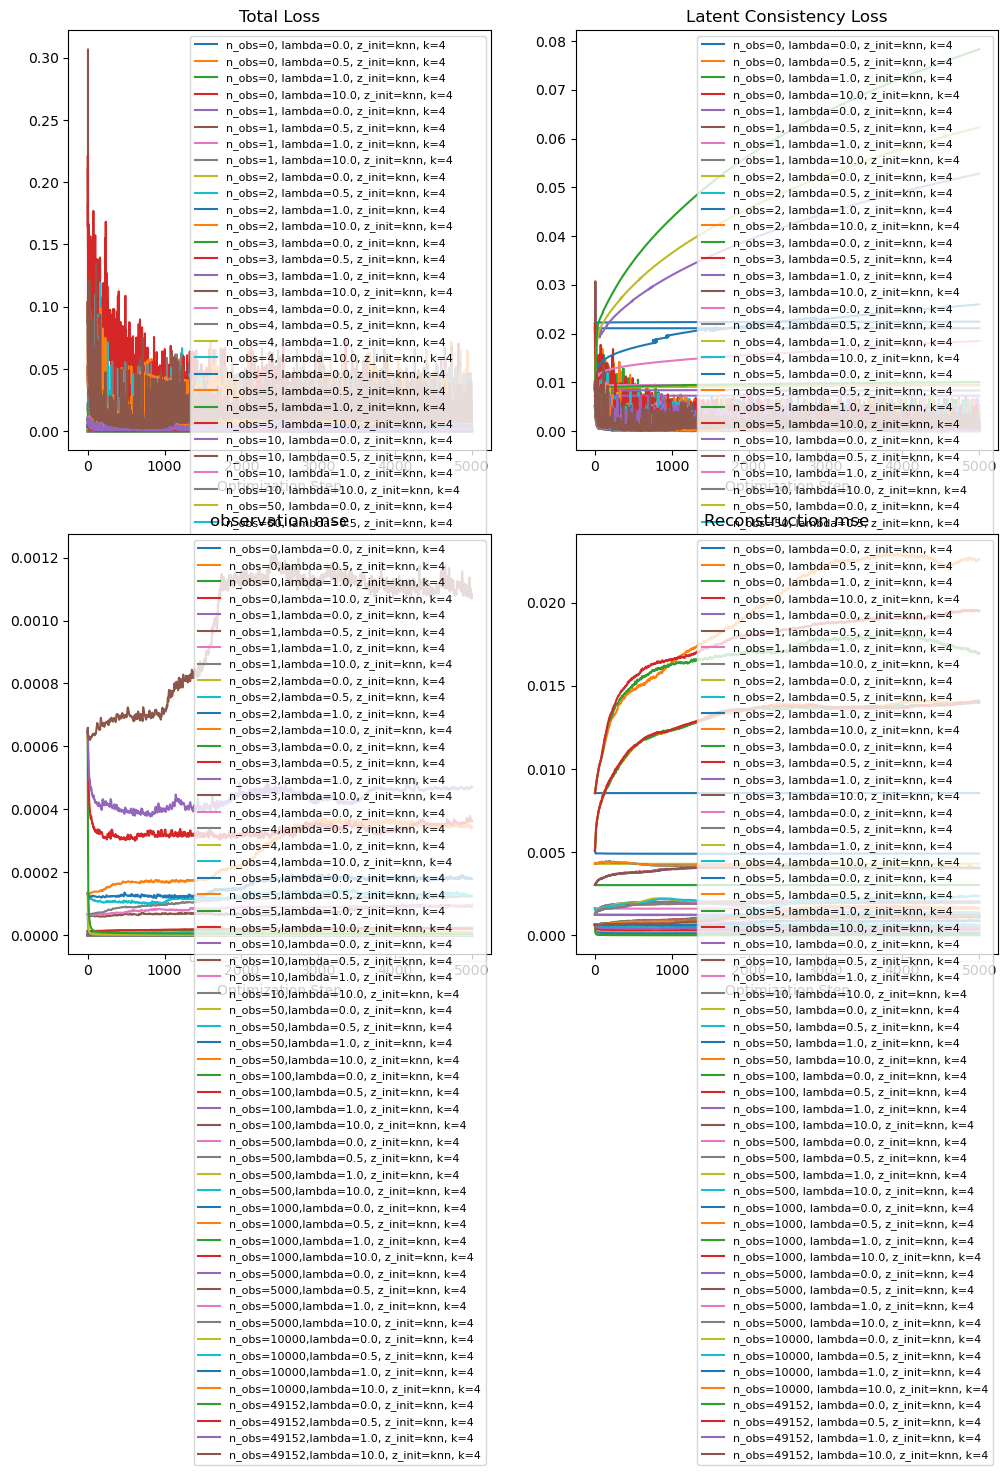

In [150]:
verbose=False
reconstruction_dict = {}

fig, axs = plt.subplots(2,2, figsize=(12,12))
for n_obs in tqdm([0,1,2,3,4,5,10,50,100,500,1000,5000,10000,obs[:,0,:,:].numel()]):#range(1,obs[:,0,:,:].numel(), 100)):
    mask = torch.zeros_like(obs[:,0,:,:])
    torch.manual_seed(42)


    numel = mask.numel()
    n = min(int(n_obs), numel)
    idx = torch.randperm(numel, device=mask.device)[:n]
    mask.view(-1)[idx] = 1
    mask = mask.unsqueeze(1).repeat(1,x.shape[1],1,1)

    reconstruction_dict[n_obs] = {}

            
    for loss_on in (["obs"]):
        for lmb in ([0.0,0.5,1.0,10.0]):
            for z_init in (["knn"]): #"knn", #"train_mean_profile", "spline_interp", "0_filled" "knn","spline_interp" "0_filled",
                if z_init == "knn":
                    k_list = [4]
                else:
                    k_list = [1]
                
                if z_init == "spline_interp":
                    sm_list = ["cubic"] # "cubic"
                else:
                    sm_list = [None]

                for k in k_list:
                    for sm in sm_list:
                        best_y_hat, best_xhat, xhat_0, history = optimize_latent_from_observations(ssp_mlic_net, obs, mask, loss_on=loss_on, x_train=x_train, y_hat_init=z_init, k=k, spline_method=sm, n_steps=5000, lr=1e-2, lam=lmb, device=device, verbose=verbose)
                        axs[0][0].plot(history['loss'], label=f"n_obs={n_obs}, lambda={lmb}, z_init={z_init}, k={k}") #'Quant={qt}, Lam={lmb}'
                        axs[1][0].plot(history['obs_diff'], label=f"n_obs={n_obs},lambda={lmb}, z_init={z_init}, k={k}")
                        axs[0][1].plot(history['latent_consistency'], label=f"n_obs={n_obs}, lambda={lmb}, z_init={z_init}, k={k}")
                        axs[1][1].plot(history['reconstruction_diff'], label=f"n_obs={n_obs}, lambda={lmb}, z_init={z_init}, k={k}")
                        reconstruction_dict[n_obs][lmb] = (best_xhat, best_y_hat, xhat_0, history)
        axs[0][0].set_title("Total Loss")
        axs[1][0].set_title("observation mse")
        axs[0][1].set_title("Latent Consistency Loss")
        axs[1][1].set_title("Reconstruction mse")

    for ax_row in axs:
        for ax in ax_row:   
            ax.set_xlabel("Optimization Step")
            ax.legend(fontsize=8)
    fig.show()

In [151]:
import pickle
with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/z_optimization_reconstruction_dict.pkl", "wb") as f:
    pickle.dump(reconstruction_dict, f)

In [36]:
with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/z_optimization_reconstruction_dict.pkl", "rb") as f:
    reconstruction_dict = pickle.load(f)

/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b

In [37]:
# axs[0][0].set_ylim(bottom=0.00000,top=0.01)
# axs[0][1].set_ylim(bottom=0.0000,top=0.01)
# axs[1][0].set_ylim(bottom=0.0000,top=0.000001644)
# axs[1][1].set_ylim(bottom=0.00,top=0.001124)

# plt.tight_layout()
# fig

In [38]:
error_per_points = {}

for k in ['loss', 'obs_diff', 'latent_consistency', 'reconstruction_diff',"relative_obs_diff"]:
    error_per_points[k] = {}
    for lmd in reconstruction_dict[0].keys():
        error_per_points[k][lmd] = []

for k in error_per_points.keys():
    for n_obs in reconstruction_dict.keys():
        for lmd in reconstruction_dict[n_obs].keys():
            _, _, _, history = reconstruction_dict[n_obs][lmd]
            if k=="relative_obs_diff":
                if n_obs==0:
                    continue
                error_per_points["relative_obs_diff"][lmd].append(history["obs_diff"][-1] / int(n_obs))
            else:
                error_per_points[k][lmd].append(history[k][-1])

In [39]:
interp_error = []
for n_obs in tqdm(reconstruction_dict.keys()):
    mask = torch.zeros_like(obs[:,0,:,:])
    torch.manual_seed(42)


    numel = mask.numel()
    n = min(int(n_obs), numel)
    idx = torch.randperm(numel, device=mask.device)[:n]
    mask.view(-1)[idx] = 1
    mask = mask.unsqueeze(1).repeat(1,x.shape[1],1,1)
    Y_obs_np = (obs*mask).detach().cpu().numpy()
    Y_filled_np = spline_reconstruct_from_sparse(Y_obs_np, method="pchip")
    interp_error.append(np.sqrt(np.mean((Y_filled_np - obs.detach().cpu().numpy())**2)))

interp_error

  0%|          | 0/14 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:11<00:00,  1.19it/s]


[np.float32(0.51701725),
 np.float32(0.5170115),
 np.float32(0.5170102),
 np.float32(0.51700467),
 np.float32(0.5170009),
 np.float32(0.516998),
 np.float32(0.5169678),
 np.float32(0.51674724),
 np.float32(0.51646984),
 np.float32(0.51437116),
 np.float32(0.51169515),
 np.float32(0.4900871),
 np.float32(0.4615681),
 np.float32(0.0)]

[np.float32(0.51701725),
 np.float32(0.5170115),
 np.float32(0.5170102),
 np.float32(0.51700467),
 np.float32(0.516998),
 np.float32(0.5169678),
 np.float32(0.51646984),
 np.float32(0.4615681),
 np.float32(0.0)]

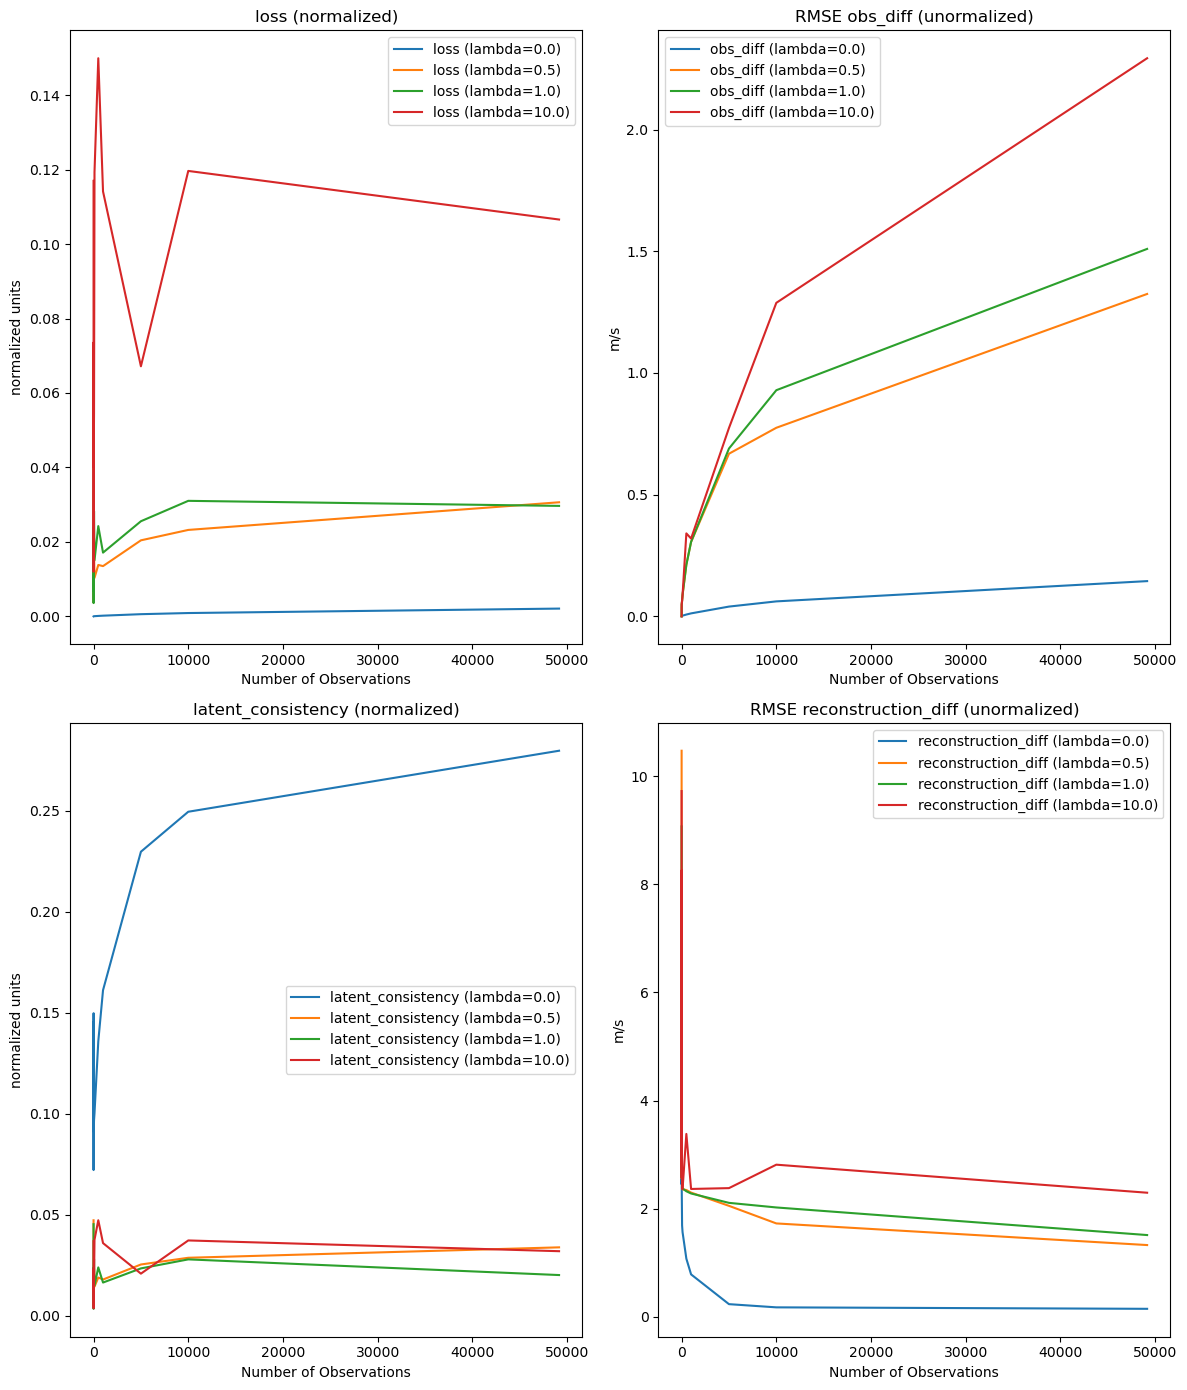

In [40]:

x_min, x_max = dm_mlic.norm_stats['params'].values()
fig,axs=plt.subplots(2,2, figsize=(12,14))
for i,loss in enumerate(['loss', 'obs_diff', 'latent_consistency', 'reconstruction_diff']):
    if "diff" in loss:
        unorm=(x_max - x_min)
        title = f"RMSE {loss} (unormalized)"
        y_axis = "m/s"

    else:
        unorm=1.0
        title = f"{loss} (normalized)"
        y_axis = "normalized units"
    for lmb in error_per_points[loss].keys():

        ax = axs.flatten()[i]
        ax.plot(list(reconstruction_dict.keys()),[np.sqrt(y)*unorm for y in error_per_points[loss][lmb]], label=f"{loss} (lambda={lmb})")
        ax.set_xlabel("Number of Observations")
        ax.set_ylabel(y_axis)
        ax.set_title(f"{title}")
        ax.legend()

plt.tight_layout()
plt.show()

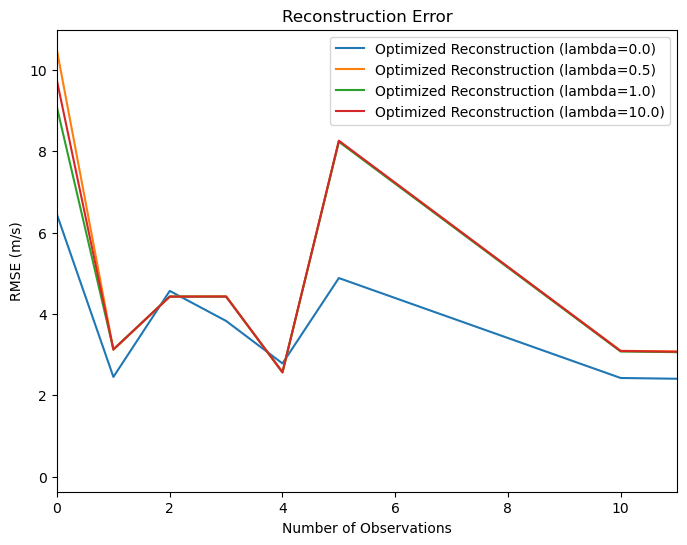

In [41]:
plt.figure(figsize=(8,6))
#plt.plot(list(reconstruction_dict.keys()), [e* (x_max - x_min) for e in interp_error], label="Spline Interpolation (cubic)")
for lmb in error_per_points["reconstruction_diff"].keys():
    plt.plot(list(reconstruction_dict.keys()), [np.sqrt(y)* (x_max - x_min) for y in error_per_points["reconstruction_diff"][lmb]], label=f"Optimized Reconstruction (lambda={lmb})")
plt.xlabel("Number of Observations")
plt.ylabel("RMSE (m/s)")
plt.title("Reconstruction Error")
plt.xlim(0,11)
plt.legend()
plt.show()

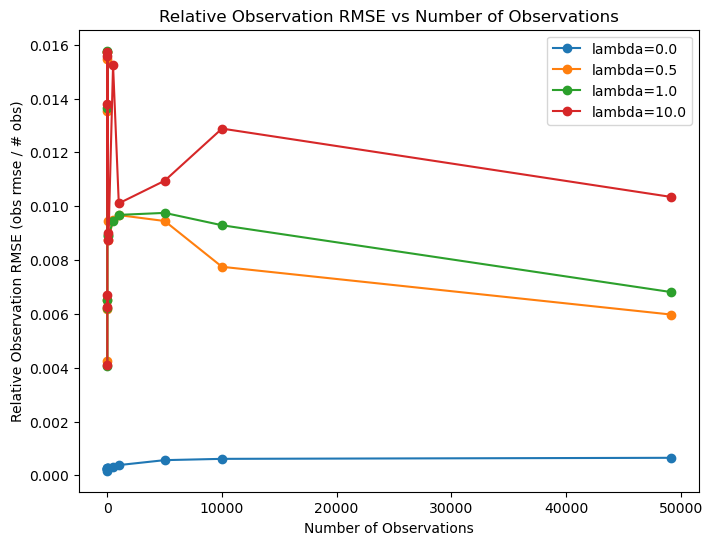

In [42]:
plt.figure(figsize=(8,6))
for lmb in error_per_points['relative_obs_diff'].keys():
    plt.plot(list(reconstruction_dict.keys())[1:], [np.sqrt(y)*unorm for y in error_per_points['relative_obs_diff'][lmb]], marker='o', label=f"lambda={lmb}")
plt.xlabel("Number of Observations")
plt.ylabel("Relative Observation RMSE (obs rmse / # obs)")
plt.title("Relative Observation RMSE vs Number of Observations")
#plt.xlim(0,100)
plt.legend()
plt.show()

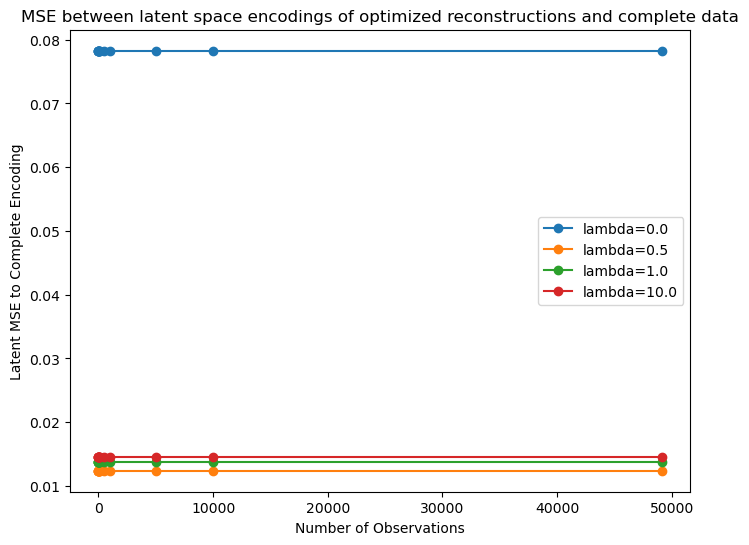

In [43]:
plt.figure(figsize=(8,6))
complete_z_hat = phi_v2(ssp_mlic_net, obs)
z_diff = {}
for n_obs in reconstruction_dict.keys():
    for lmb in reconstruction_dict[n_obs].keys():
        _, y_hat_opt, _ , _ = reconstruction_dict[n_obs][lmb]
        z_diff[lmb] = (complete_z_hat - y_hat_opt).pow(2).mean().item()

for lmb in z_diff.keys():
    plt.plot(list(reconstruction_dict.keys()), [z_diff[lmb] for n in reconstruction_dict.keys()], marker='o', label=f"lambda={lmb}")
plt.xlabel("Number of Observations")
plt.ylabel("Latent MSE to Complete Encoding")
plt.title("MSE between latent space encodings of optimized reconstructions and complete data")

plt.legend()
plt.show()

        #print(f"n_obs={n_obs}, lambda={lmb}, final obs mse={history['obs_diff'][-1]:.6e}, final recon mse={history['reconstruction_diff'][-1]:.6e}")

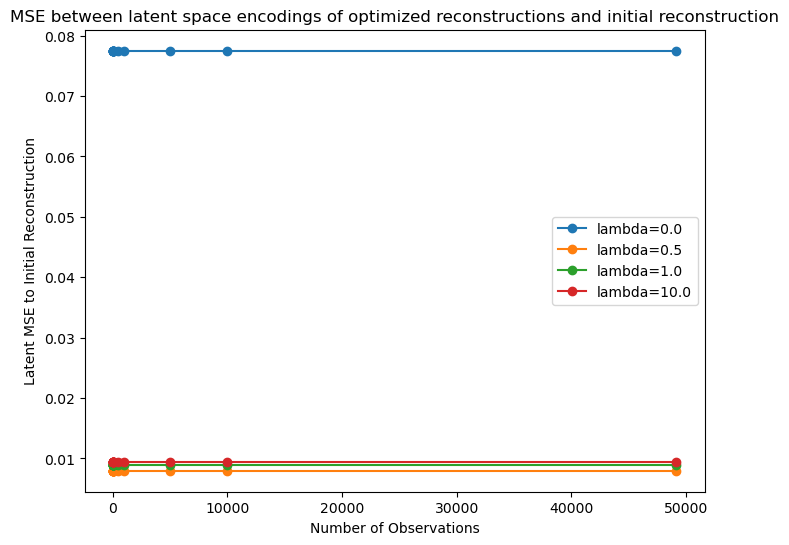

In [44]:
plt.figure(figsize=(8,6))

z_diff = {}
for n_obs in reconstruction_dict.keys():
    for lmb in reconstruction_dict[n_obs].keys():
        _, y_hat_opt, x0 , _ = reconstruction_dict[n_obs][lmb]
        y0_hat = phi_v2(ssp_mlic_net, x0)
        z_diff[lmb] = (y0_hat - y_hat_opt).pow(2).mean().item()

for lmb in z_diff.keys():
    plt.plot(list(reconstruction_dict.keys()), [z_diff[lmb] for n in reconstruction_dict.keys()], marker='o', label=f"lambda={lmb}")
plt.xlabel("Number of Observations")
plt.ylabel("Latent MSE to Initial Reconstruction")
plt.title("MSE between latent space encodings of optimized reconstructions and initial reconstruction")

plt.legend()
plt.show()


In [45]:
import tqdm
import torch
import numpy as np
import pandas as pd

def oi(
        outgrid_da,
        patcher_cls,
        obs,
        obs_var='ssh',
        lt=pd.to_timedelta('7D'), lx=1., ly=1.,
        noise=0.05,
        obs_dt=pd.to_timedelta('1D'),
        obs_dx=0.25,
        obs_dy=0.25,
        device='cuda'
    ):
    """
    outgrid_da: xr.DataArray with (time, lat, lon) dims and coords with target region, period and resolution, will be updated inplace
    patcher_cls: callable that return an DataArray iterator of slices of outgrid_da to be sequentially solved for
    obs: xr.Dataset of observations with (time, lat, lon) coords
    obs_var: observation values to be interpolated
    lt: time decorellation factor for covariance model
    lx: longitudinal decorellation factor for covariance model
    ly: latitudinal decorellation factor for covariance model
    noise: noise variance
    obs_dt: temporal bin size for obs coarsening 
    obs_dx: longitudinal bin size for obs coarsening 
    obs_dy: latitudinal bin size for obs coarsening 
    device: torch device to run oi on 'cpu' or 'cuda' gpu
    
    Returns: xr.DataArray outgrid_da filled with interpolation
    """

    patcher = patcher_cls(outgrid_da)
    # 1 Iterate over each patch
    for p in tqdm.tqdm(patcher):
        # 2 select observations within 2 stds in each direction
        pobs = obs.where(
            (np.isfinite(obs[obs_var].values))
        &  (obs.time >= (p.time.min() - 2 * lt))
        &  (obs.time <= (p.time.max() + 2 * lt))
        &  (obs.lat >= (p.lat.min() - 2 * ly))
        &  (obs.lat <= (p.lat.max() + 2 * ly))
        &  (obs.lon >= (p.lon.min() - 2 * lx))
        &  (obs.lon <= (p.lon.max() + 2 * lx)), drop=True
        )
        if pobs.time.size == 0:
            continue

        # 3 Coarsen the observations to a certain resolution
        df = pobs.to_dataframe().reset_index().dropna()
        time_bins = pd.date_range(df['time'].min(), df['time'].max() + obs_dt, freq=obs_dt)
        lat_bins = np.arange(df['lat'].min(), df['lat'].max() + obs_dx, obs_dx)
        lon_bins = np.arange(df['lon'].min(), df['lon'].max() + obs_dy, obs_dy)

        ## bin
        df['time_bin'] = pd.cut(df['time'], time_bins)
        df['lat_bin'] = pd.cut(df['lat'], lat_bins)
        df['lon_bin'] = pd.cut(df['lon'], lon_bins)

        ## Average data within each bin
        df_averaged = df.groupby(['time_bin', 'lat_bin', 'lon_bin'], observed=True).mean(numeric_only=False).reset_index()
        pobs_coarse = df_averaged.dropna().set_index('time')[[obs_var, 'lat', 'lon']].to_xarray()

        # Create flat coordinates and values array
        obs_values, obs_time, obs_lat, obs_lon = pobs_coarse[obs_var].values, pobs_coarse.time.values, pobs_coarse.lat.values, pobs_coarse.lon.values
        gtime, glat, glon = (np.ravel(x) for x in np.meshgrid(p.time, p.lat, p.lon, indexing='ij'))

        # Convert to torch tensor
        d0 = pd.to_datetime("2017-01-01").to_datetime64()
        _obs_time = (obs_time - d0) / lt
        _gtime = (gtime -d0) / lt
        _lt = lt / lt
        (
            tobs_values, tobs_time, tobs_lat, tobs_lon,
            tgtime, tglat, tglon
        ) = (
            torch.from_numpy(t).to(device).float()
            for t in [
                obs_values, _obs_time, obs_lat, obs_lon,
                _gtime, glat, glon
            ]
        )

        # 4 Solve oi
        BHt = torch.exp(
                - ((tgtime[:, None] - tobs_time[None, :]) / _lt)**2
                - ((tglon[:, None] - tobs_lon[None, :]) / lx)**2
                - ((tglat[:, None] - tobs_lat[None, :]) / ly)**2
            )
        HBHt = torch.exp(-((tobs_time[:, None] - tobs_time[None, :]) / _lt)**2 -
                        ((tobs_lon[:, None] - tobs_lon[None, :]) / lx)**2 -
                        ((tobs_lat[:, None] - tobs_lat[None, :]) / ly)**2)

        nobs = len(tobs_time)
        R = torch.diag(torch.full((nobs,), noise**2, device=tobs_time.device))


        Coo = HBHt + R
        Mi = torch.linalg.inv(Coo)
        Iw = torch.mm(BHt, Mi)
        sol=torch.mv(Iw, tobs_values)

        # fill in outputput da
        p[:] = sol.detach().cpu().numpy().reshape(p.shape)

    return outgrid_

## Profiles

In [46]:
obs_arr = obs.detach().cpu().numpy()

In [47]:
mask = torch.zeros_like(obs[:,0,:,:])
torch.manual_seed(42)
n_obs = 1

numel = mask.numel()
n = min(int(n_obs), numel)
idx = torch.randperm(numel, device=mask.device)[:n]
mask.view(-1)[idx] = 1
mask = mask.unsqueeze(1).repeat(1,x.shape[1],1,1)

In [48]:
profiles_idx = ((mask[:,0,:,:] == 1).nonzero(as_tuple=False))
idx = profiles_idx[0].detach().cpu().numpy()
t,lat,lon = idx[0], idx[1], idx[2]
t,lat,lon

(np.int64(0), np.int64(13), np.int64(50))

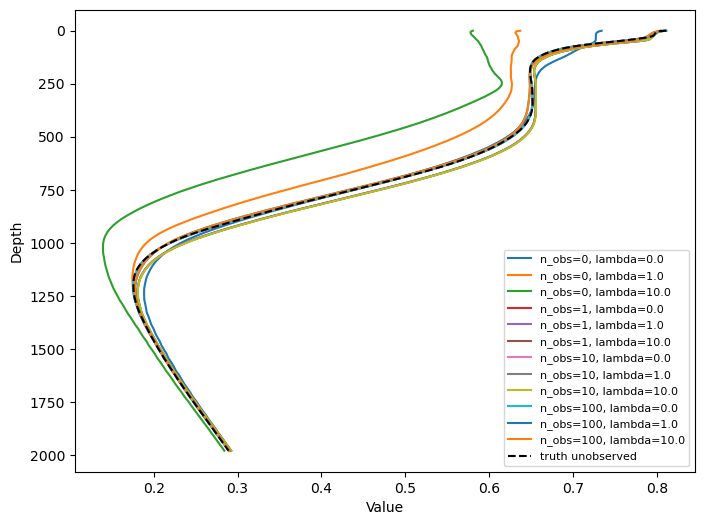

In [49]:
fig,ax = plt.subplots(1,1, figsize=(8,6))
for n_obs in [0,1,10,100]:#reconstruction_dict.keys():
    for lmb in [0.0,1.0,10.0]:#reconstruction_dict[n_obs].keys():
        arr = reconstruction_dict[n_obs][lmb]
        best_xhat, _,_, history = arr
        best_xhat = best_xhat.detach().cpu().numpy()
        ax.plot(best_xhat[t,:,lat,lon],depth_array, label=f"n_obs={n_obs}, lambda={lmb}")
ax.plot(obs_arr[t,:,lat,lon],depth_array, 'k--', label="truth unobserved")
ax.set_xlabel("Value")
ax.set_ylabel("Depth")

ax.legend(fontsize=8)
fig.gca().invert_yaxis()

plt.show()

In [73]:
reconstruction_dict.keys()

dict_keys([0, 1, 2, 3, 4, 5, 10, 50, 100, 500, 1000, 5000, 10000, 49152])

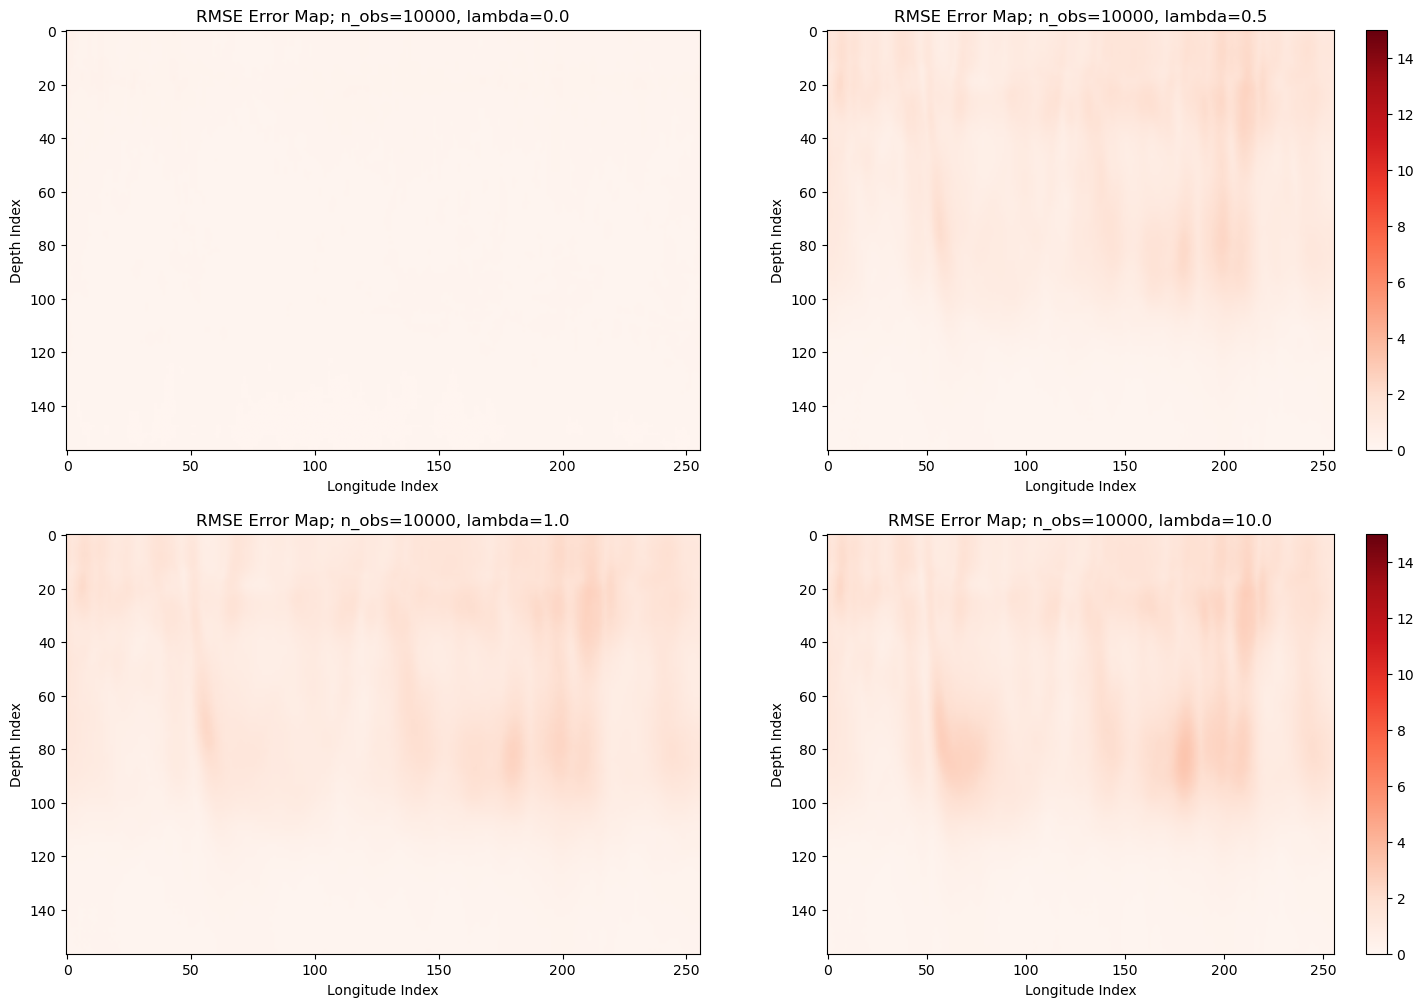

In [75]:
fig, axs = plt.subplots(2,2, figsize=(18,12))
im_right = []
n_obs = 10000
for i,lmb in enumerate(reconstruction_dict[n_obs].keys()):
    best_xhat, _, _, _ = reconstruction_dict[n_obs][lmb]
    error = (x_max-x_min) * np.sqrt((obs_arr - best_xhat.detach().cpu().numpy())**2).mean(axis=(0,2))
    ax = axs.flatten()[i]
    im = ax.imshow(error, aspect='auto', cmap='Reds', vmin=0, vmax=15)
    ax.set_title(f"RMSE Error Map; n_obs={n_obs}, lambda={lmb}")
    ax.set_xlabel("Longitude Index")
    ax.set_ylabel("Depth Index")
    if i % 2 == 1:
        im_right.append(im)



fig.colorbar(im_right[0],ax=axs[0,1], orientation='vertical')
fig.colorbar(im_right[1],ax=axs[1,1], orientation='vertical')

plt.show()


In [51]:
i

3